# CSCIE89 - Basic CNN in PyTorch (Problem 1: MNIST via torchvision)

In this notebook, we will build a **basic convolutional neural network (CNN)** that recognizes handwritten digits from 0 to 9. This is the homework version of the class notebook (`1_pytorch_basic_cnn_digits.ipynb`): instead of the small `digits` image dataset that comes with scikit-learn (8 x 8 images), we use the **MNIST dataset from `torchvision`**, where each image is **28 x 28**.

Our Objectives:

1. Load and inspect image data.
2. Divide data into training, validation, and test sets.
3. convert NumPy arrays into PyTorch tensors and data loaders.
4. Define a small, vanilla CNN.
5. Train the model while tracking loss and accuracy.
6. Evaluate it on data it has never seen.
7. Visualize learning curves, a confusion matrix, and predictions.
8. Run inference on a few images of our own handwriting.

> **Why do we have Train/test/valid?** The training set teaches the model. The validation set helps us observe learning without touching the final test set ( think unit testiong) . The test set gives an unbiased final estimate of performance ( this is dataset in your managers drawer).

## 1. Setup and imports

If an import fails, make sure you have all right packages installed. Ask for help on Ed dicussions or email the cscie89 teaching staff

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# PROBLEM 1 CHANGE: torchvision replaces sklearn.datasets.load_digits
# as the source of images (MNIST instead of the tiny 8 x 8 digits set).
from torchvision import datasets

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Random processes are used when splitting and shuffling data and when
# initializing model weights. A fixed seed makes results more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Apple Silicon use MPS; laptops with NVIDIA GPUs can use CUDA.
# This dataset also trains quickly on a CPU. So dont worry
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")


PyTorch version: 2.14.0+cu130
Using device: cpu


## 2. Load and explore the images

Each example is a 28 x 28 grayscale image from the **MNIST** dataset (loaded via `torchvision.datasets.MNIST`, downloaded automatically the first time this cell runs). Pixel values range from 0 (dark) to 255 (bright), and the target is the digit shown in the image.

Images shape: (60000, 28, 28)
Labels shape: (60000,)
Pixel range: 0 to 255
Classes: [0 1 2 3 4 5 6 7 8 9]


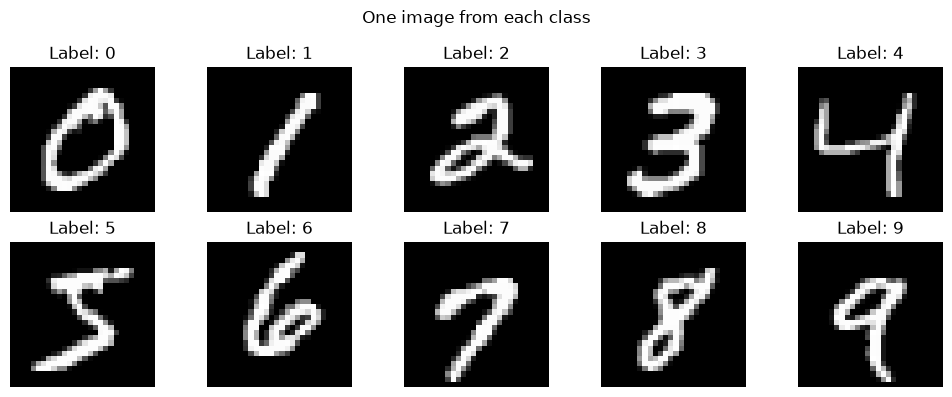

In [2]:
# PROBLEM 1 CHANGE: this whole cell replaces `digits = load_digits()`.
# torchvision downloads MNIST (28 x 28 images) instead of using the
# bundled 8 x 8 sklearn `digits` dataset. One dataset object (like
# `digits`), then unpack .data/.targets instead of .images/.target.
mnist = datasets.MNIST(root="./data", train=True, download=True)
images = mnist.data.numpy()      # Shape: (number of images, height, width)
labels = mnist.targets.numpy()   # One integer label for every image
class_names = np.arange(10)      # digit labels 0-9, replacing digits.target_names

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Pixel range: {images.min()} to {images.max()}")
print(f"Classes: {class_names}")

# Display one example from each class.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    example_index = np.where(labels == digit)[0][0]
    ax.imshow(images[example_index], cmap="gray")
    ax.set_title(f"Label: {digit}")
    ax.axis("off")
plt.suptitle("One image from each class")
plt.tight_layout()
plt.show()


## 3. Create training, validation, and test datasets

We use 70% of the images for training, 15% for validation, and 15% for testing. `stratify=labels` keeps roughly the same proportion of each digit in every split.

We also divide every pixel by 255, changing the range from 0-255 to 0-1. Neural networks generally train more smoothly with small, consistently scaled inputs.

In [3]:
# First reserve 30% for validation + testing reaming 70% for training.
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, random_state=SEED, stratify=labels
)

# Split that remaining 30% evenly: 15% validation and 15% test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

def make_image_tensor(array):
    """Convert images to float tensors with CNN shape (N, C, H, W).

    N = number of images, C = channels, H = height, W = width.
    Grayscale images have one channel, so unsqueeze(1) adds C = 1.
    """
    # PROBLEM 1 CHANGE: divide by 255 (MNIST pixel range 0-255), not by 16
    # (the sklearn `digits` pixel range was 0-16).
    return torch.tensor(array, dtype=torch.float32).unsqueeze(1) / 255.0

X_train_t = make_image_tensor(X_train)
X_val_t = make_image_tensor(X_val)
X_test_t = make_image_tensor(X_test)

# CrossEntropyLoss expects class labels to be 64-bit integers (torch.long).
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"Training:   {len(X_train_t):5d} images ({len(X_train_t)/len(images):.0%})")
print(f"Validation: {len(X_val_t):5d} images ({len(X_val_t)/len(images):.0%})")
print(f"Test:       {len(X_test_t):5d} images ({len(X_test_t)/len(images):.0%})")
print(f"One CNN batch will have shape (batch, channel, height, width).")
print(f"One image tensor has shape: {X_train_t[0].shape}")


Training:   42000 images (70%)
Validation:  9000 images (15%)
Test:        9000 images (15%)
One CNN batch will have shape (batch, channel, height, width).
One image tensor has shape: torch.Size([1, 28, 28])


## 4. Put the data into DataLoaders

We will use  `TensorDataset` that pairs every image with its label. And also `DataLoader` which serves small batches to the model. Training data is shuffled each epoch so the model does not learn from a fixed ordering. Validation and test data do not need shuffling.

`train_generator` creates a random-number generator with a fixed starting point. in our case it controls how the DataLoader shuffles the training images


In [4]:
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# The generator makes the shuffled training order reproducible.
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=train_generator
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch_images, batch_labels = next(iter(train_loader))
print(f"Image batch shape: {batch_images.shape}")
print(f"Label batch shape: {batch_labels.shape}")


Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


## 5. Define a vanilla CNN

The network has two conceptual parts:

- **Feature extractor:** convolution layers slide small filters across the image. ReLU adds non-linearity, and max pooling reduces width and height.
- **Classifier:** the feature maps are flattened into a vector and passed to a linear layer that produces 10 class scores, called **logits**.

Shape changes: `(1, 28, 28) → (8, 28, 28) → (8, 14, 14) → (16, 14, 14) → (16, 7, 7) → 784 → 10`.

In [5]:
class BasicCNN(nn.Module):  # a new network, built by subclassing PyTorch's base Module class
    """A small CNN for 28 x 28, one-channel images."""

    def __init__(self):  # constructor: runs once, when BasicCNN() is created, to build the layers
        super().__init__()  # runs nn.Module's own setup so PyTorch can track this model's layers/weights

        self.features = nn.Sequential(  # groups the convolution/pooling layers into one callable block
            # Padding=1 keeps height and width at 28 x 28.
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),  # slides 8 filters over the image to detect simple patterns
            nn.ReLU(),  # zeroes out negative values, adding the non-linearity needed to learn more than straight lines
            # Pooling changes 28 x 28 into 14 x 14.
            nn.MaxPool2d(kernel_size=2),  # keeps the strongest value in each 2x2 block, halving height and width

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),  # slides 16 filters over those 8 feature maps to detect more complex patterns
            nn.ReLU(),  # same non-linearity as above
            # Pooling changes 14 x 14 into 7 x 7.
            nn.MaxPool2d(kernel_size=2),  # halves height and width again
        )

        self.classifier = nn.Sequential(  # groups the layers that turn features into class scores
            nn.Flatten(),                    # 16 feature maps x 7 x 7 = 784 values  -- collapses each image's feature maps into one long vector
            # PROBLEM 1 CHANGE: 16 * 7 * 7 (28x28 input pooled twice), not
            # 16 * 2 * 2 (the original 8x8 input pooled twice).
            nn.Linear(16 * 7 * 7, 32),  # fully connected layer: maps the 784 values down to 32
            nn.ReLU(),  # non-linearity again
            nn.Linear(32, 10),              # One score for each digit  -- fully connected layer producing one logit per class
        )

    def forward(self, x):  # defines how input data flows through the model when the model is called
        x = self.features(x)  # runs the image through the convolution/pooling block
        return self.classifier(x)  # runs the extracted features through the classifier block and returns logits

model = BasicCNN().to(device)  # creates the model and moves its weights to the chosen device (CPU/GPU)
print(model)  # prints the model's layer structure

# Confirm that a batch produces one row of 10 scores per image.
with torch.no_grad():  # disables gradient tracking since we're only checking output shape, not training
    example_output = model(batch_images.to(device))  # runs one batch of images through the model
print(f"Model output shape: {example_output.shape}")  # expect (batch_size, 10)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")  # counts every learnable weight/bias in the model


BasicCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)
Model output shape: torch.Size([64, 10])
Trainable parameters: 26,698


## 6. Loss, optimizer, and evaluation function

`CrossEntropyLoss` compares the 10 raw class scores with the correct class. It already performs the softmax-related mathematics internally, so we **do not add a softmax layer** to the model.

The Adam optimizer updates weights to reduce loss. During evaluation, `model.eval()` turns off training-only behavior, and `torch.no_grad()` avoids storing gradients, saving memory.

In [6]:
criterion = nn.CrossEntropyLoss()  # the loss function: compares predicted logits to the true labels
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)  # updates the model's weights using gradients, at this learning rate

def evaluate(model, data_loader, criterion, device):  # computes loss/accuracy on a dataset without training the model
    """Return average loss and accuracy without changing model weights."""
    model.eval()  # switches to evaluation mode (disables dropout and similar training-only behavior)
    total_loss = 0.0       # running sum of loss across all batches seen so far
    total_correct = 0      # running count of correct predictions
    total_examples = 0     # running count of images processed

    with torch.no_grad():  # disables gradient tracking since we're not training here, saving memory/compute
        for inputs, targets in data_loader:  # loops over the data one batch at a time
            inputs = inputs.to(device)   # moves this batch's images to the chosen device (CPU/GPU)
            targets = targets.to(device)  # moves this batch's labels to the same device

            logits = model(inputs)               # runs the batch through the model to get raw class scores
            loss = criterion(logits, targets)    # computes this batch's average loss
            predictions = logits.argmax(dim=1)   # picks the highest-scoring class as the predicted digit

            # Multiply by batch size because loss is an average for this batch.
            total_loss += loss.item() * inputs.size(0)              # undoes that averaging, adds this batch's total loss
            total_correct += (predictions == targets).sum().item()  # adds this batch's number of correct predictions
            total_examples += inputs.size(0)                        # adds this batch's size to the running total

    return total_loss / total_examples, total_correct / total_examples  # overall average loss and accuracy across the whole dataset


## 7. Train the model

For each batch, training follows five steps:
            clear old gradients,
            make predictions,
            calculate loss,
            calculate gradients with backpropagation,
            and update the weights.

One complete pass through the training set is an **epoch**.

Logits are the raw scores the model produces for each possible class.
Logits are not probabilities: they can be negative and don't need to sum to 1.

 Digit:  0    1     2    3    4    5    6    7    8    9
 Logits:
        [0.2, -1.0, 0.5, 3.1, 0.0, 0.8, -0.4, 1.2, 0.3, 0.1]

The highest score is 3.1 at index 3, so the predicted digit is 3.

During training, pass these raw scores directly to CrossEntropyLoss, PyTorch's nn.CrossEntropyLoss already includes the probability-conversion calculation, so you give it the raw logits.

Conceptually, it does two things:
1. Converts logits into probabilities using softmax.
2. Calculates the loss from the probability assigned to the correct class

If you apply softmax first, CrossEntropyLoss treats those probabilities as raw scores and normalizes them again, changing the intended calculation.

In [7]:
# PROBLEM 1 CHANGE: 12 epochs instead of 30. MNIST's ~42,000-image
# training split is about 35x larger than the tiny digits training
# split, so fewer epochs are needed to reach high accuracy while
# keeping training time reasonable.
EPOCHS = 12
history = {
    "train_loss": [], "train_accuracy": [],
    "val_loss": [], "val_accuracy": [],
}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_examples = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()          # 1. Clear gradients from the previous batch.
        logits = model(inputs)         # 2. Forward pass: compute class scores.
        loss = criterion(logits, targets)  # 3. Measure prediction error.
        loss.backward()                # 4. Backward pass: compute gradients.
        optimizer.step()               # 5. Update the model's weights.

        predictions = logits.argmax(dim=1)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (predictions == targets).sum().item()
        running_examples += inputs.size(0)

    train_loss = running_loss / running_examples
    train_accuracy = running_correct / running_examples
    val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f}, accuracy {train_accuracy:.3f} | "
        f"val loss {val_loss:.4f}, accuracy {val_accuracy:.3f}"
    )


Epoch 01/12 | train loss 0.2808, accuracy 0.913 | val loss 0.1122, accuracy 0.965


Epoch 02/12 | train loss 0.0863, accuracy 0.974 | val loss 0.0810, accuracy 0.974


Epoch 03/12 | train loss 0.0622, accuracy 0.981 | val loss 0.0751, accuracy 0.977


Epoch 04/12 | train loss 0.0504, accuracy 0.984 | val loss 0.0633, accuracy 0.980


Epoch 05/12 | train loss 0.0440, accuracy 0.987 | val loss 0.0572, accuracy 0.983


...

Epoch 08/12 | train loss 0.0297, accuracy 0.990 | val loss 0.0594, accuracy 0.984


Epoch 09/12 | train loss 0.0269, accuracy 0.991 | val loss 0.0742, accuracy 0.978


Epoch 10/12 | train loss 0.0228, accuracy 0.993 | val loss 0.0649, accuracy 0.981


Epoch 11/12 | train loss 0.0197, accuracy 0.993 | val loss 0.0636, accuracy 0.981


Epoch 12/12 | train loss 0.0198, accuracy 0.993 | val loss 0.0649, accuracy 0.983


## 8. Plot the learning curves

Loss measures error (lower is better), while accuracy is the fraction predicted correctly (higher is better). If training keeps improving while validation gets worse, the model may be overfitting.

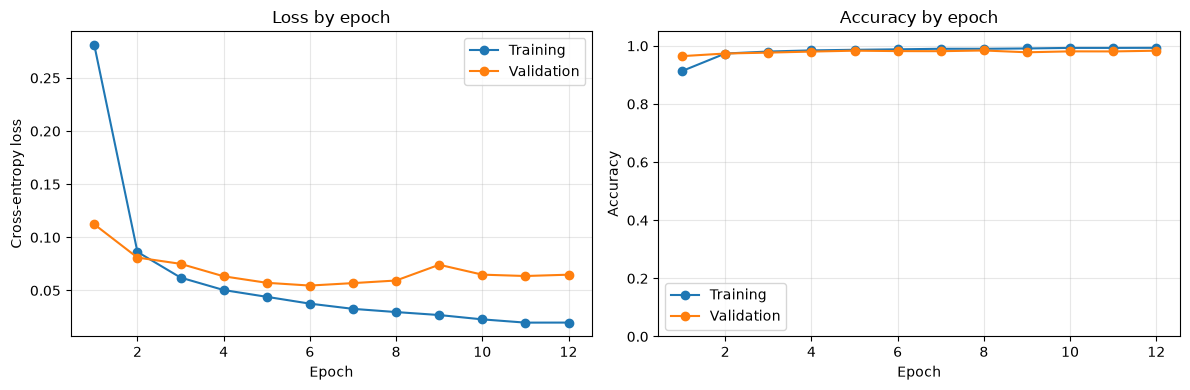

In [8]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Training")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation")
axes[0].set(title="Loss by epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Training")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation")
axes[1].set(title="Accuracy by epoch", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.05))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Final evaluation on the untouched test set

We use the test set only after training is finished. Besides overall loss and accuracy, the classification report shows precision, recall, and F1-score for every digit. The confusion matrix shows which digits are confused with one another.

Test loss:     0.0628
Test accuracy: 98.46%


Accuracy check with scikit-learn: 98.46%

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       888
           1       1.00      0.98      0.99      1011
           2       0.97      0.99      0.98       893
           3       0.99      0.98      0.99       920
           4       0.99      0.98      0.98       877
           5       0.99      0.99      0.99       813
           6       0.99      0.99      0.99       888
           7       0.98      0.99      0.98       940
           8       0.97      0.98      0.98       877
           9       0.98      0.98      0.98       893

    accuracy                           0.98      9000
   macro avg       0.98      0.98      0.98      9000
weighted avg       0.98      0.98      0.98      9000



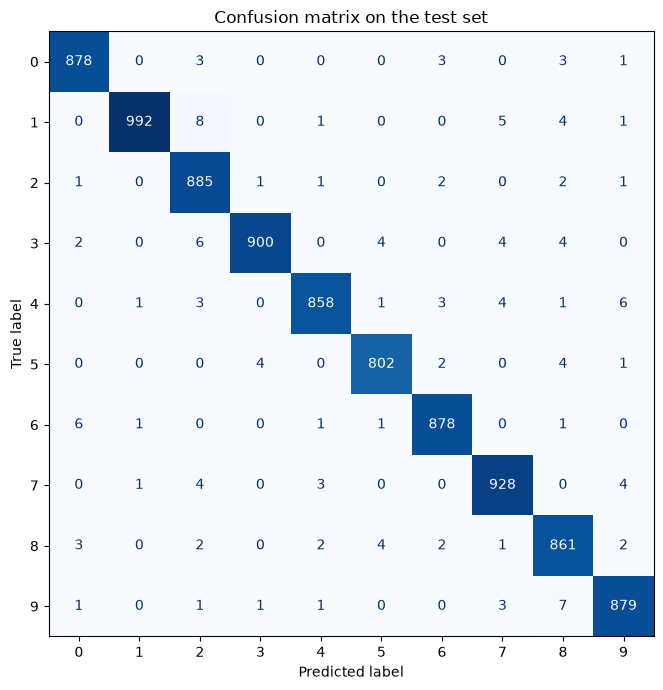

In [9]:
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

# Collect every test prediction on the CPU for scikit-learn metrics.
model.eval()
all_predictions = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        logits = model(inputs.to(device))
        predictions = logits.argmax(dim=1).cpu()
        all_predictions.extend(predictions.numpy())
        all_targets.extend(targets.numpy())

print(f"Accuracy check with scikit-learn: {accuracy_score(all_targets, all_predictions):.2%}")
print("\nClassification report:")
print(classification_report(all_targets, all_predictions, target_names=[str(x) for x in class_names]))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    all_targets, all_predictions, display_labels=class_names, cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()


### How to read the metrics

- **Accuracy:** proportion of all predictions that were correct.
- **Precision for a digit:** when the model predicts this digit, how often is it correct?
- **Recall for a digit:** of all real examples of this digit, how many did the model find?
- **F1-score:** a combined measure of precision and recall.
- **Support:** number of test examples belonging to that digit.
- **Confusion matrix:** correct predictions are on the main diagonal; off-diagonal cells are mistakes.

## 10. Look at individual predictions

A metric summarizes performance, but seeing individual examples makes the result more concrete. Green titles are correct predictions and red titles are mistakes.

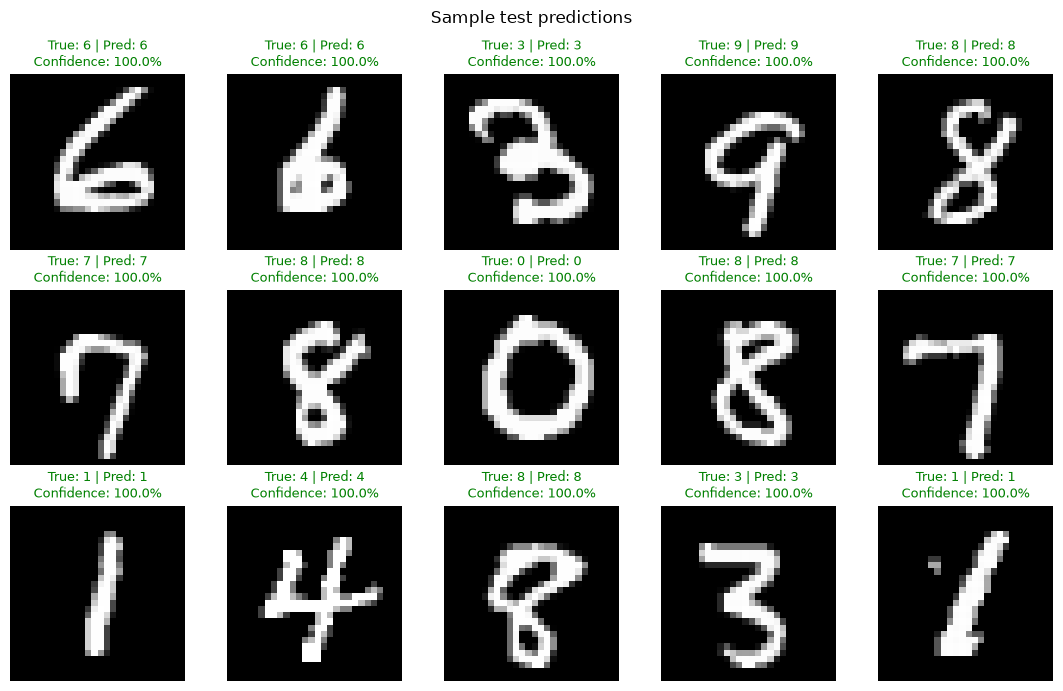

In [10]:
# Use a fixed random generator so the displayed sample is repeatable.
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_test_t), size=15, replace=False)

model.eval()
with torch.no_grad():
    sample_logits = model(X_test_t[sample_indices].to(device))
    sample_probabilities = torch.softmax(sample_logits, dim=1).cpu()
    sample_predictions = sample_probabilities.argmax(dim=1)

fig, axes = plt.subplots(3, 5, figsize=(11, 7))
for ax, index, prediction, probabilities in zip(
    axes.flat, sample_indices, sample_predictions, sample_probabilities
):
    actual = int(y_test_t[index])
    predicted = int(prediction)
    confidence = float(probabilities[predicted])
    color = "green" if predicted == actual else "red"

    ax.imshow(X_test_t[index, 0], cmap="gray")
    ax.set_title(
        f"True: {actual} | Pred: {predicted}\nConfidence: {confidence:.1%}",
        color=color, fontsize=9
    )
    ax.axis("off")

plt.suptitle("Sample test predictions")
plt.tight_layout()
plt.show()


## 11. Save and reload the trained model (optional)

Saving a `state_dict` stores the learned weights. To use them later, create the same architecture and load the weights into it.

In [11]:
# PROBLEM 1 CHANGE: renamed from "basic_cnn_digits.pth" to reflect the
# MNIST-trained weights saved here.
MODEL_PATH = "basic_cnn_mnist.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved weights to {MODEL_PATH}")

# Example reload:
reloaded_model = BasicCNN().to(device)
reloaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
reloaded_model.eval()
reloaded_loss, reloaded_accuracy = evaluate(reloaded_model, test_loader, criterion, device)
print(f"Reloaded model test accuracy: {reloaded_accuracy:.2%}")


Saved weights to basic_cnn_mnist.pth


Reloaded model test accuracy: 98.46%


## 12. Inference on your own handwriting (Problem 1)

Drop a few photos of digits you've drawn by hand into the `handwritten_digits/` folder (any image format, roughly square crops work best) and run this section. Each image is converted to grayscale, resized to 28 x 28, and inverted/scaled to match MNIST's white-digit-on-black-background convention (same `/255.0` scaling used in Section 3) before being fed to the trained model. This is **inference only** — the model is not retrained here. Per the assignment ("do not overdo this"), just a handful of images is enough.


In [12]:
import os
from PIL import Image

HANDWRITTEN_DIR = "handwritten_digits"
IMAGE_EXTS = (".png", ".jpg", ".jpeg")
os.makedirs(HANDWRITTEN_DIR, exist_ok=True)  # creates the folder if it does not exist yet

# Add your own handwritten digit photos to this folder, then run this cell.
existing = sorted(f for f in os.listdir(HANDWRITTEN_DIR) if f.lower().endswith(IMAGE_EXTS))

if not existing:
    print(f"No images found in '{HANDWRITTEN_DIR}/' -- add a few handwritten digit photos there and re-run this cell.")
else:
    print(f"Running inference on {len(existing)} image(s): {existing}")

    def preprocess_handwritten(path):  # loads an image file and prepares it for the model
        img = Image.open(path).convert("L").resize((28, 28), Image.LANCZOS)  # grayscale, MNIST size
        arr = np.array(img).astype(np.float32) / 255.0  # scale to [0, 1], same as training data

        # Dark strokes on a light background (typical of a photo) get inverted
        # so digits are white-on-black, matching MNIST's convention.
        if arr.mean() > 0.5:
            arr = 1.0 - arr

        tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).float()  # add batch + channel dims: (1, 1, 28, 28)
        return tensor, arr

    model.eval()  # inference only -- no training happens in this section
    fig, axes = plt.subplots(1, len(existing), figsize=(3 * len(existing), 3), squeeze=False)  # squeeze=False keeps a 2D grid even for 1 image

    for ax, fname in zip(axes[0], existing):
        tensor, display_arr = preprocess_handwritten(os.path.join(HANDWRITTEN_DIR, fname))
        with torch.no_grad():  # no gradients needed for inference
            probabilities = torch.softmax(model(tensor.to(device)), dim=1).cpu().squeeze(0)
            pred = int(probabilities.argmax())
            confidence = float(probabilities[pred])

        ax.imshow(display_arr, cmap="gray")
        ax.set_title(f"{fname}\npredicted: {pred} ({confidence:.1%})")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


No images found in 'handwritten_digits/' -- add a few handwritten digit photos there and re-run this cell.


## Summary

Through this example we have used a CNN and seen a full image-classification workflow: data loading, splitting, preprocessing, batching, CNN construction, training, validation, final testing, metrics, visualization, and saving weights — this time on the full 28 x 28 MNIST dataset from `torchvision` instead of the tiny 8 x 8 `digits` dataset. We finished with inference-only predictions on a few images of our own handwriting.